In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision  
import matplotlib.pyplot as plt
from nflows import flows, distributions, transforms
from nflows.transforms.normalization import ActNorm
from tqdm import tqdm

from src.diffeomorphisms.image.starflow import StarFlowImageDiffeomorphism
from src.distributions.star_gaussians.multi_inverse_pre_bias_linear_norm_gaussian import MultiInversePreBiasLinearStarNormGaussianDistribution
from src.embedding.hyperbolic_gromov_monge import HyperbolicGromovMongeEmbedding
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.isometrized_euclidean.image import l2IsometrizedImageEuclidean
from src.training.gromov_monge_starflow import GromovMongeEmbeddingInformedStarFlowTraining
from src.transforms.image.to_vec import ToVecImageTransform
from src.transforms.image.parity_conv.linear_2d import Linear2DParityConvImageTransform
from src.transforms.image.parity_conv.simple_tanh_2d import SimpleTanh2DParityConvImageTransform

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# fix seed
torch.manual_seed(31)
# fix dtype
torch.set_default_dtype(torch.float64)

# set experiment parameters
size = 16

batch_size = 128
latent_dim = 5
# stage 1
num_epoch_emb = 2
learning_rate_emb = 1e-3
# stage 2
num_epochs_flow = 50
learning_rate_flow = 1e-3

results_folder = os.path.join("results", "mnist", f"{size}x{size}")
os.makedirs(results_folder, exist_ok=True)

### Construct data set ###

In [2]:
# Construct dataset
H, W = size, size
mnist_mean = 0.1307
mnist_var = 0.3081

# Define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# Load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Create train and validation subsets
data_train, data_val = random_split(full_dataset, [train_size, val_size])

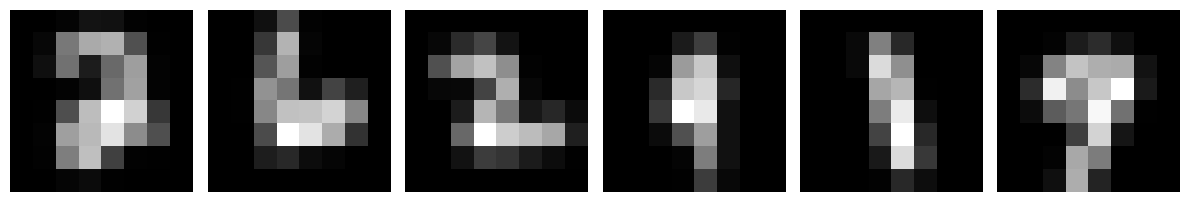

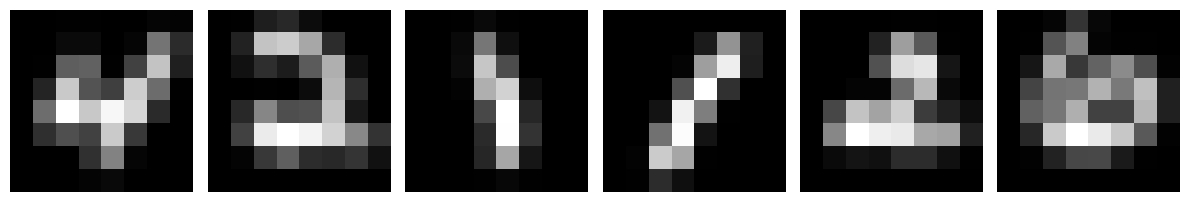

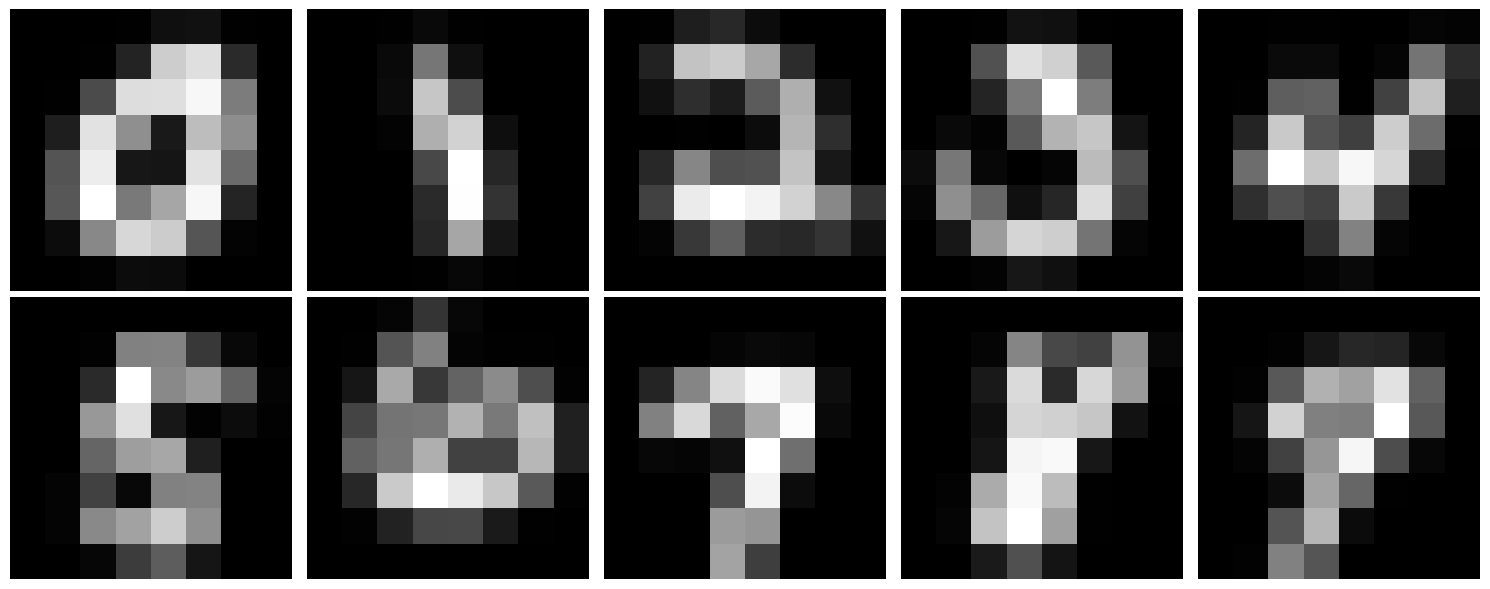

In [3]:
class RandomPairDataset(Dataset):
    def __init__(self, data):
        self.data = data            # shape: N x d
        self.N = data.__len__()

    def __len__(self):
        return self.N  # you can pick another value if you wish

    def __getitem__(self, idx):
        # x: deterministic sample (makes training deterministic per epoch)
        x, y = self.data[idx]
        # x_prime: random sample, different from idx
        idx2 = torch.randint(0, self.N - 1, (1,)).item()
        if idx2 >= idx:
            idx2 += 1
        x_prime, y_prime = self.data[idx2]
        return (x, y), (x_prime, y_prime)
    
# create dataset and dataloader
train_pair_dataset = RandomPairDataset(data_train)
train_loader = DataLoader(train_pair_dataset, batch_size=batch_size, shuffle=True)
val_pair_dataset = RandomPairDataset(data_val)
val_loader = DataLoader(val_pair_dataset, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples, train_examples_prime = next(iter(train_loader))
train_images, train_labels = train_examples
train_images_prime, train_labels_prime = train_examples_prime
val_examples, val_examples_prime = next(iter(val_loader))
val_images, val_labels = val_examples
val_images_prime, val_labels_prime = val_examples_prime

# construct data clusters as one digit per class
val_clusters = []
for digit in range(10):
    digit_indices = (val_labels == digit).nonzero(as_tuple=True)[0]
    digit_images = val_images[digit_indices][0]
    val_clusters.append(digit_images.unsqueeze(0))

cluster_images = torch.cat(val_clusters, dim=0)
cluster_labels = torch.arange(10)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# plot cluster images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
for i in range(10):
    axes[i].imshow(cluster_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Embed data set ###

In [4]:
# construct Gromov-Monge Embedding in Hyperbolic Space
# construct convolutional neural network architecture
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(x + self.block(x))

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, stride=2, padding=1),  # size/2
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            ResidualBlock(64),

            nn.Conv2d(64, 128, 3, stride=2, padding=1),  # size/4
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            ResidualBlock(128),
        )
        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, latent_dim)

    def forward(self, x):
        # x: [B, 1, H, W] with arbitrary H=W=size
        x = self.conv(x)              # [B, 128, H', W']
        x = x.mean(dim=(2, 3))        # global average pooling -> [B, 128]
        x = F.relu(self.fc1(x))       # [B, 512]
        z = self.fc2(x)               # [B, latent_dim]
        return z
        
    
# instantiate the neural network
input_dim = size
hidden_dim = 20
output_dim = latent_dim  # we will embed into 2D hyperbolic space
nn_model = Encoder(output_dim)

# instantiate Gromov-Monge Embedding
T = HyperbolicGromovMongeEmbedding(nn_model, output_dim=output_dim)

In [5]:
# construct train loop
optimizer = torch.optim.Adam(T.nn_model.parameters(), lr=learning_rate_emb)
for epoch in range(num_epoch_emb):
    epoch_loss = 0.0
    for (x, y), (x_prime, y_prime) in tqdm(train_loader):
        N = x.size(0)
        optimizer.zero_grad()
        dist_data = torch.norm(x.reshape(N, -1) - x_prime.reshape(N, -1), dim=1)
        dist_emb = T.distance(x, x_prime)
        loss = torch.log((1 + dist_emb ** 2) / (1 + dist_data ** 2)).pow(2).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * N
    epoch_loss /= len(train_pair_dataset)
    print(f"Epoch {epoch+1}/{num_epoch_emb}, Loss: {epoch_loss:.6f}")


100%|██████████| 375/375 [00:17<00:00, 20.97it/s]


Epoch 1/2, Loss: 0.091932


100%|██████████| 375/375 [00:17<00:00, 20.96it/s]

Epoch 2/2, Loss: 0.041469


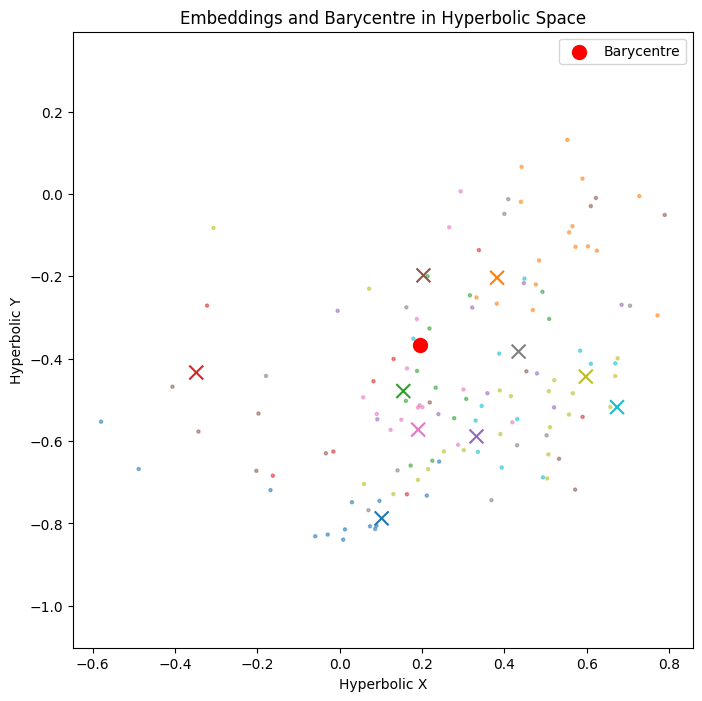

In [6]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings = T(train_images).cpu().numpy()
    cluster_embeddings = T(cluster_images).cpu().numpy()
    barycentre = T.barycentre(train_images)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings[:, 0], train_embeddings[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings[:, 0], cluster_embeddings[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre[0].item(), barycentre[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final.png"))
plt.show()  

In [7]:
# translate origin with isometr
# check that distances are preserved I: compute old distances
with torch.no_grad():
    dist_emb = T.distance(cluster_images[1:], cluster_images[:-1])

# update origin
T.set_origin(barycentre)

# check that distances are preserved II: compute new distances
with torch.no_grad():
    dist_emb_centered = T.distance(cluster_images[1:], cluster_images[:-1])

print("Pairwise distance matrix in embedding space between cluster centers:")
print((dist_emb - dist_emb_centered).abs().max())  # should be close to zero

Pairwise distance matrix in embedding space between cluster centers:
tensor(1.1546e-14)


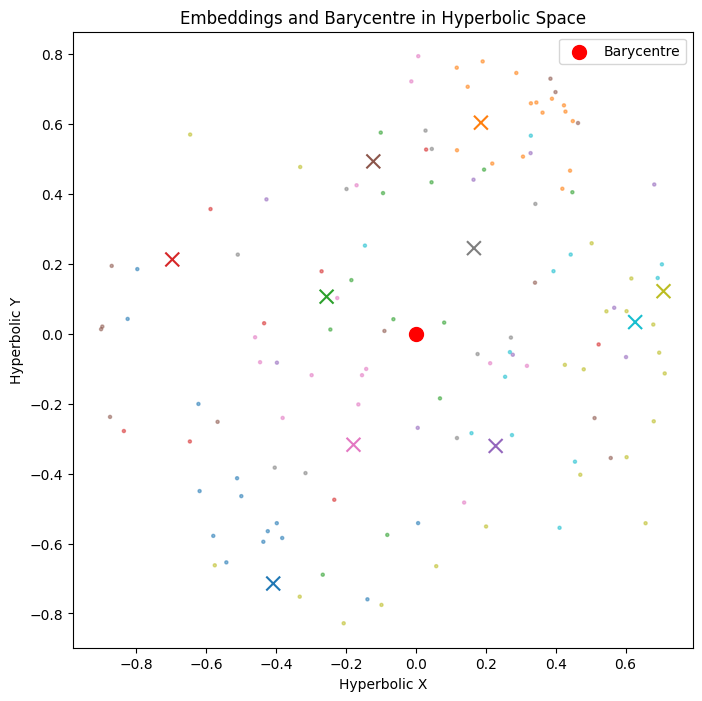

Distance between barycentres before and after centering:
6.1637435114954075e-06


In [8]:
# we would like to compute the barycentre of the embeddings and use this to center the embeddings
with torch.no_grad():
    train_embeddings_centered = T(train_images).cpu().numpy()
    cluster_embeddings_centered = T(cluster_images).cpu().numpy()
    barycentre_centered = T.barycentre(train_images)

plt.figure(figsize=(8, 8))
plt.scatter(train_embeddings_centered[:, 0], train_embeddings_centered[:, 1], c=train_labels.cpu().numpy(), s=5, alpha=0.5, cmap='tab10')
plt.scatter(cluster_embeddings_centered[:, 0], cluster_embeddings_centered[:, 1], c=cluster_labels.cpu().numpy(), marker='x', s=100, cmap='tab10')
plt.scatter(barycentre_centered[0].item(), barycentre_centered[1].item(), color='red', marker='o', s=100, label='Barycentre')
plt.title("Embeddings and Barycentre in Hyperbolic Space")
plt.xlabel("Hyperbolic X")
plt.ylabel("Hyperbolic Y")
plt.axis('equal')
plt.legend()
plt.savefig(os.path.join(results_folder,"emb_final_centered.png"))
plt.show()  

# check difference between barycentres
print("Distance between barycentres before and after centering:")
translated_barycentre = T.translate(barycentre, barycentre)
print((translated_barycentre - barycentre_centered).norm().item())  # should be close to zero

### Learn embedding-informed pullback geometry ###

In [ ]:
# construct normalizing flow model
class SimpleStarFlowImageDiffeomorphism(StarFlowImageDiffeomorphism):
    def __init__(self, in_channels, height, width, kernel_size, hidden_channels, n_flows, n_modes):
        super(SimpleStarFlowImageDiffeomorphism, self).__init__(in_channels, height, width, self.create_flow_model(in_channels, height, width, kernel_size, hidden_channels, n_flows, n_modes))

    def create_flow_model(self, in_channels, height, width, kernel_size, hidden_channels, n_flows, n_modes):
        base_dist = MultiInversePreBiasLinearStarNormGaussianDistribution(in_channels * height * width, n_modes)
        transforms_list = []
        for i in range(n_flows):
            transforms_list.append(ActNorm(features=in_channels))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i))
            transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=i+1))
            transforms_list.append(SimpleTanh2DParityConvImageTransform(in_channels, height, width, hidden_channels=hidden_channels, kernel_size=kernel_size, parity=i))
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows))
        transforms_list.append(Linear2DParityConvImageTransform(in_channels, height, width, kernel_size, parity=n_flows+1))
        transforms_list.append(ToVecImageTransform(in_channels, height, width))
        flow_transforms = transforms.CompositeTransform(transforms_list)
        return flows.Flow(transform=flow_transforms, distribution=base_dist)

# instantiate flow model
in_channels = 1
height = size
width = size
kernel_size = 3
hidden_channels = 2
n_flows = 2
n_modes = 10
star_flow_diffeo = SimpleStarFlowImageDiffeomorphism(in_channels, height, width, kernel_size, hidden_channels, n_flows, n_modes)
    
# instantiate HGME-informed normalizing flow
reg_param = 1.
gme_star_flow = GromovMongeEmbeddingInformedStarFlowTraining(T, star_flow_diffeo, reg_param=reg_param)
# freeze embedding model parameters
for param in gme_star_flow.emb.parameters():
    param.requires_grad = False

In [10]:
# construct train loop
optimizer_hgme_nflow = torch.optim.Adam(list(gme_star_flow.star_flow_diffeo.parameters()) , lr=learning_rate_flow) 
for epoch in range(num_epochs_flow):
    epoch_loss = 0.0
    for (x, _), _ in tqdm(train_loader):
        optimizer_hgme_nflow.zero_grad()
        loss = gme_star_flow.loss(x)
        loss.backward()
        optimizer_hgme_nflow.step()
        epoch_loss += loss.item() * x.size(0)
    epoch_loss /= len(train_pair_dataset)
    print(f"Flow Epoch {epoch+1}/{num_epochs_flow}, Loss: {epoch_loss:.6f}")

100%|██████████| 375/375 [00:11<00:00, 32.22it/s]


Flow Epoch 1/50, Loss: 58.942036


100%|██████████| 375/375 [00:11<00:00, 32.91it/s]


Flow Epoch 2/50, Loss: -5.701357


100%|██████████| 375/375 [00:11<00:00, 32.98it/s]


...

Flow Epoch 11/50, Loss: -149.889697


100%|██████████| 375/375 [00:11<00:00, 33.72it/s]


Flow Epoch 12/50, Loss: -155.835517


 26%|██▋       | 99/375 [00:03<00:08, 32.85it/s]


KeyboardInterrupt: 

In [11]:
# construct manifold from learned flow
manifold = StandardPullbackImageEuclidean(gme_star_flow.star_flow_diffeo)
# construct iso_manifold 
# iso_manifold = l2IsometrizedImageEuclidean(manifold)

torch.Size([10, 1, 8, 8]) torch.Size([10, 1, 8, 8])
Reconstruction error of cluster images through learned diffeomorphism: 0.000000


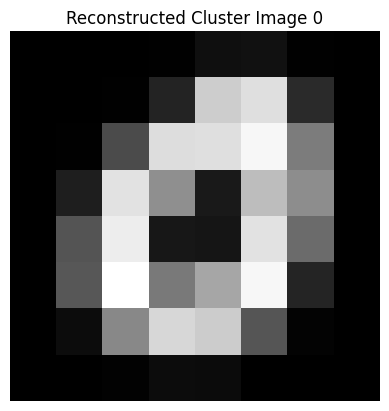

In [12]:
# debug diffeomorphism
with torch.no_grad():
    mapped_cluster_images = gme_star_flow.star_flow_diffeo(cluster_images)
    rec_cluster_images = gme_star_flow.star_flow_diffeo.inverse(mapped_cluster_images)

print(cluster_images.shape, rec_cluster_images.shape)

# print reconstruction error
reconstruction_error = torch.norm((cluster_images - rec_cluster_images).reshape(10,-1), dim=1).mean().item()
print(f"Reconstruction error of cluster images through learned diffeomorphism: {reconstruction_error:.6f}")

plt.imshow(rec_cluster_images[0].squeeze().cpu(), cmap='gray')
plt.title("Reconstructed Cluster Image 0")
plt.axis('off')
plt.show()

Max difference between geodesic endpoints and original images: 2.5746370366092705e-14


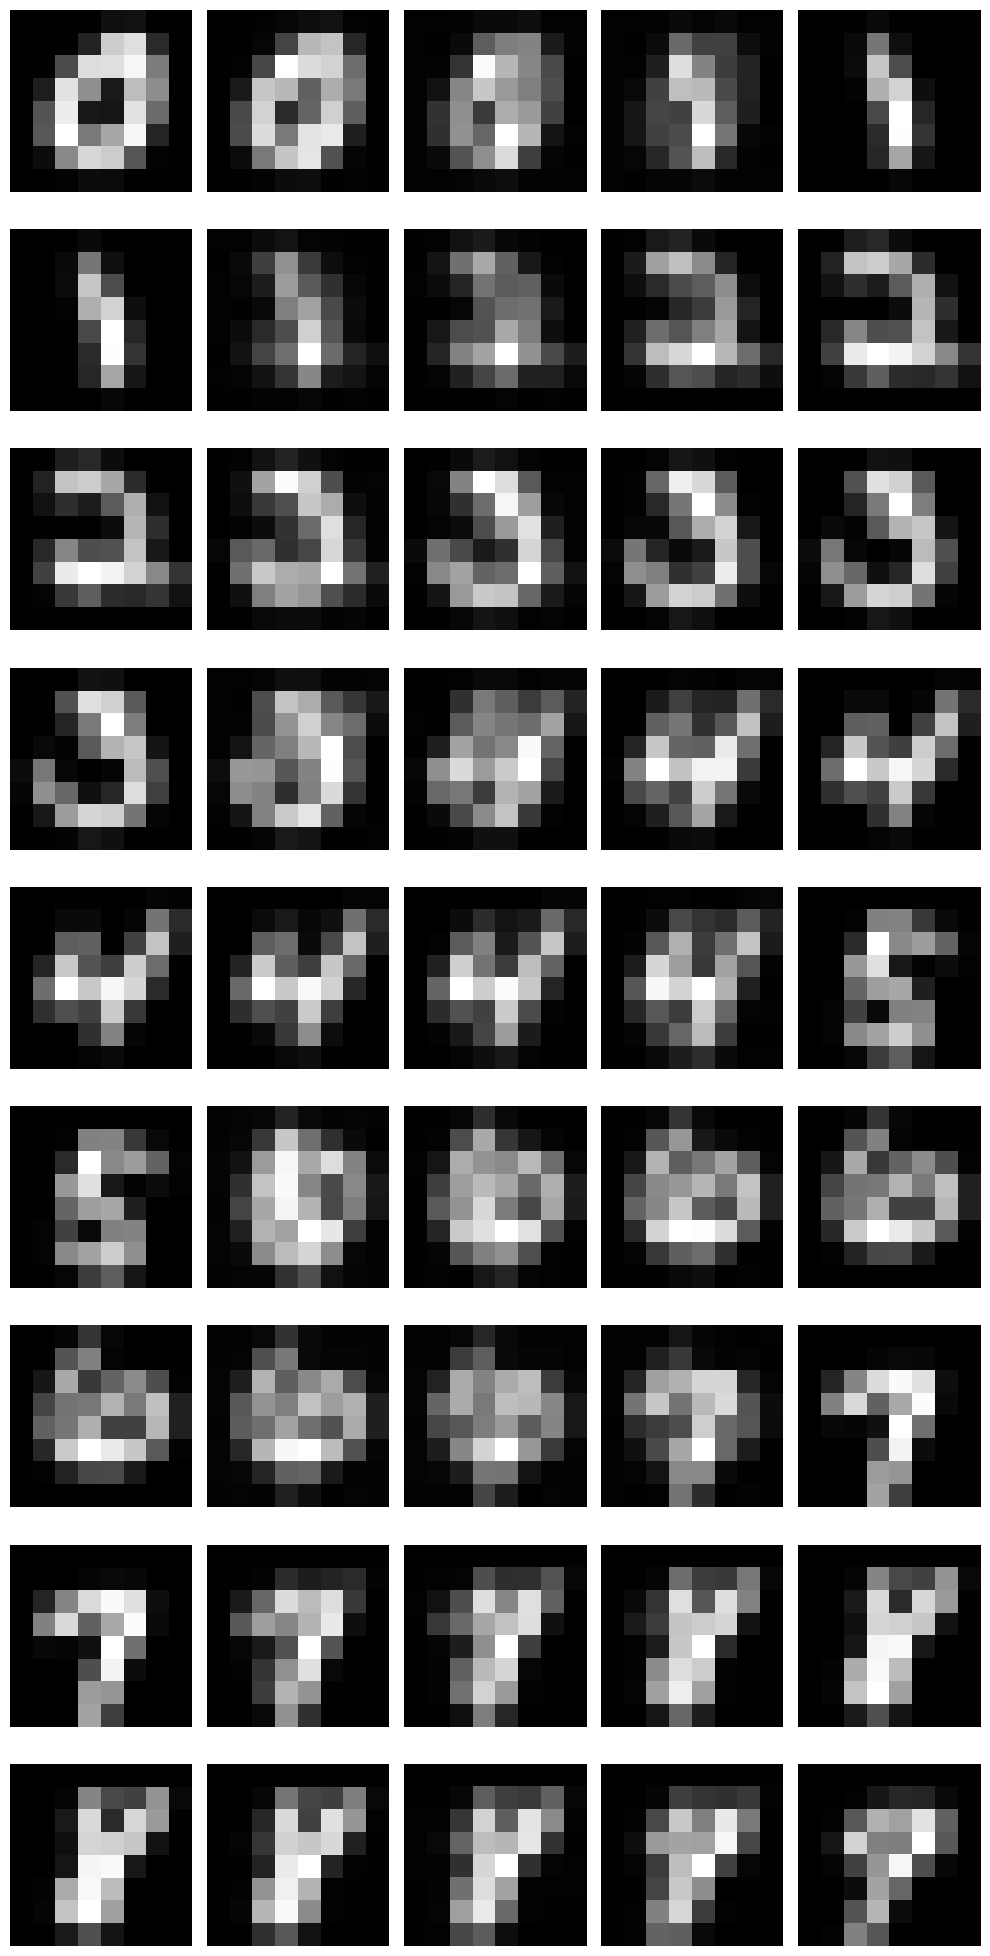

In [14]:
# compute geodesics between all pairs of points
K = 5
t = torch.linspace(0, 1, steps=K)
with torch.no_grad():
    geodesics = manifold.geodesic(cluster_images[None], cluster_images[None], t)


# plot difference between geodesic endpoints and original images
endpoint_diff = torch.norm((geodesics[0, :, 0, 0] - cluster_images).reshape(10, -1), dim=1)
print("Max difference between geodesic endpoints and original images:", endpoint_diff.max().item())

# plot geodesics
# plot cluster images
fig, axes = plt.subplots(9, K, figsize=(int(K / 10 * 20), 20))
axes = axes.flatten()
for i in range(10-1):
    for k in range(K):
        axes[i*K + k].imshow(geodesics[0, i, i+1, k, 0], cmap='gray')
        # axes[i*K + k].imshow(val_images[0].squeeze(), cmap='gray')
        axes[i*K + k].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(results_folder,"data_geodesics.png"))
plt.show()

In [ ]:
# # sanity check: is the embedding still the same (and was not accidentally changed during flow training)
# with torch.no_grad():
#     train_embeddings_after_flow = gme_star_flow.emb(train_images)
# print("Max difference in embeddings before and after flow training:", (train_embeddings_after_flow - train_embeddings_centered).abs().max().item())  # should be close to zero

Max difference in embeddings before and after flow training: 0.0


/var/folders/7n/h6r1srp97v78dhwb2rxn_k5m0000gn/T/ipykernel_50996/839288662.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print("Max difference in embeddings before and after flow training:", (train_embeddings_after_flow - train_embeddings_centered).abs().max().item())  # should be close to zero
